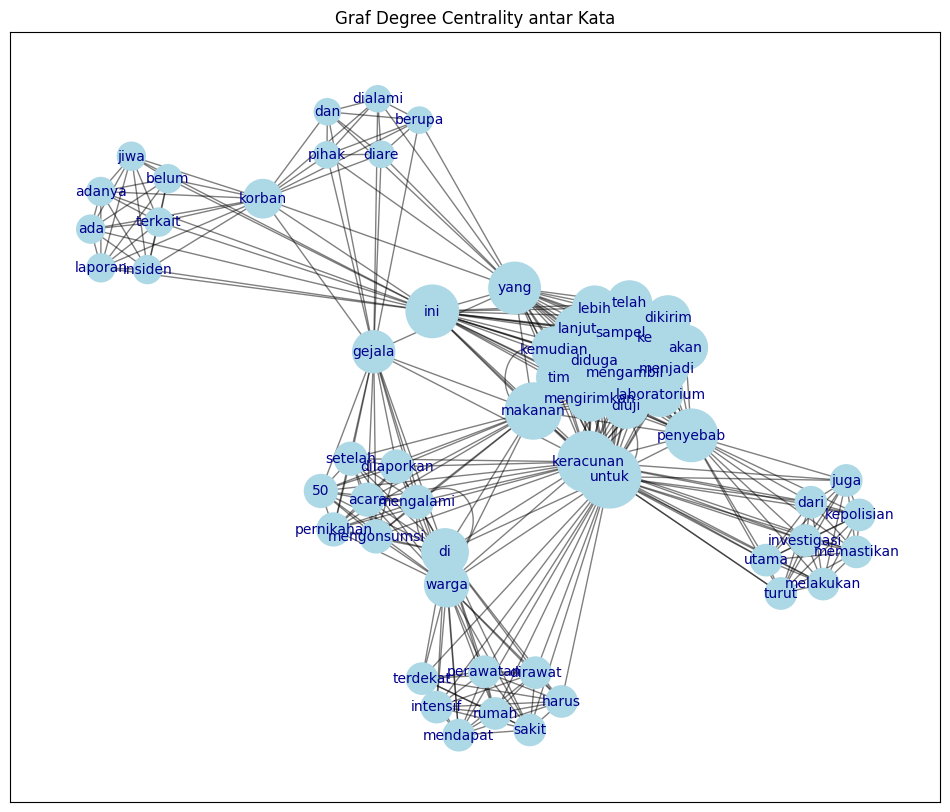

Kata-kata Penting Berdasarkan Degree Centrality:
 ['untuk', 'keracunan', 'makanan', 'penyebab', 'ini', 'yang', 'di']


In [1]:
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.feature_extraction.text import TfidfVectorizer
from itertools import combinations

# Fungsi untuk membangun graf berdasarkan kata
def build_word_graph(text, top_n=5):
    # Pisahkan teks menjadi kalimat
    sentences = text.split('. ')

    # Hitung TF-IDF pada kata-kata
    tfidf_vectorizer = TfidfVectorizer()
    tfidf_matrix = tfidf_vectorizer.fit_transform(sentences)
    feature_names = tfidf_vectorizer.get_feature_names_out()

    # Inisialisasi graf
    G = nx.Graph()

    # Buat graf berdasarkan co-occurrence kata dalam setiap kalimat
    for sentence in sentences:
        words = [word for word in sentence.split() if word in feature_names]
        for word1, word2 in combinations(words, 2):
            if G.has_edge(word1, word2):
                G[word1][word2]['weight'] += 1
            else:
                G.add_edge(word1, word2, weight=1)

    # Hitung degree centrality untuk setiap kata
    degree_centrality = nx.degree_centrality(G)

    # Tampilkan graf dengan centrality sebagai ukuran node
    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(G, seed=42)
    nx.draw_networkx_nodes(G, pos, node_size=[v * 3000 for v in degree_centrality.values()], node_color='lightblue')
    nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.5)
    nx.draw_networkx_labels(G, pos, font_size=10, font_color='darkblue')

    plt.title("Graf Degree Centrality antar Kata")
    plt.show()

    # Menampilkan kata-kata penting berdasarkan degree centrality
    important_words = sorted(degree_centrality, key=degree_centrality.get, reverse=True)[:top_n]
    return important_words

# Pengujian dengan input teks baru
input_text = """
Sebanyak 50 warga di Kabupaten Banyuwangi dilaporkan mengalami gejala keracunan setelah mengonsumsi makanan di acara pernikahan. Beberapa warga harus dirawat di rumah sakit terdekat untuk mendapat perawatan intensif.
Menurut pihak Dinas Kesehatan, gejala yang dialami korban berupa pusing, mual, muntah, dan diare. Dinas Kesehatan Kabupaten Banyuwangi telah mengirimkan tim untuk mengambil sampel makanan yang diduga menjadi penyebab keracunan tersebut.
Sampel makanan ini kemudian akan dikirim ke laboratorium untuk diuji lebih lanjut. Hingga kini, belum ada laporan adanya korban jiwa terkait insiden ini. Pihak kepolisian juga turut melakukan investigasi untuk memastikan penyebab utama dari keracunan tersebut.
"""

# Menampilkan graf dan kata-kata penting
important_words = build_word_graph(input_text, top_n=7)
print("Kata-kata Penting Berdasarkan Degree Centrality:\n", important_words)
